## DMEPOS-Supplier Data Carpentry

The purpose of this notebook is to clean the DMEPOS-by Supplier dataset for exploration and ML modeling.

Some of the cleaning steps involved:
- Assessed data structure, quality, and consistency
- Identified missing and suppressed values
- Added a Year column
- Reordered columns for consistency
- Combined all three years into a single dataset
- Imputed missing vlaues where nedded. 

For information regarding each variable, please refer to the data dictionary downloadable from [DMEPOS - by Supplier](https://data.cms.gov/provider-summary-by-type-of-service/medicare-durable-medical-equipment-devices-supplies/medicare-durable-medical-equipment-devices-supplies-by-supplier).

End result: 

Saved the cleaned dataset to a shared team directory: /dsa/groups/casestudycf25/team02/silver/dmepos_suplr_clean.csv

## Loading the data and quick exploration

In [1]:
# Loading Libraries
import re
import pandas as pd
import csv
from pathlib import Path

Using Path function to verify if the files exist by simply listing all files and folders in the specified directory, printing their names.

In [2]:
for f in Path("/dsa/groups/casestudycf25/team02/").iterdir():
    print(f.name)

Taxonomy Code List Dec 2023.csv
casestudycf25t02.sqlite.db
OWNRSHP_PGYR2021_2023.csv
bronze
silver
gold
ownership_payment_clean.csv


Loading the 3 CSV files into separate pandas dataframes.

In [3]:
df21 = pd.read_csv("/dsa/groups/casestudycf25/team02/bronze/mup_dme_ry25_p05_v20_dy21_supr.csv",na_values=["NA"])
df22 = pd.read_csv("/dsa/groups/casestudycf25/team02/bronze/mup_dme_ry25_p05_v20_dy22_supr.csv",na_values=["NA"])
df23 = pd.read_csv("/dsa/groups/casestudycf25/team02/bronze/mup_dme_ry25_p05_v10_dy23_supr.csv",na_values=["NA"])

Taking a quick peak at the dataframes to see if everything is loaded.  I can also see the structure of the datasets.

In [4]:
df21.head()

,Suplr_NPI,Suplr_Prvdr_Last_Name_Org,Suplr_Prvdr_First_Name,Suplr_Prvdr_MI,Suplr_Prvdr_Crdntls,Suplr_Prvdr_Ent_Cd,Suplr_Prvdr_St1,Suplr_Prvdr_St2,Suplr_Prvdr_City,Suplr_Prvdr_State_Abrvtn,...,Bene_CC_PH_Diabetes_V2_Pct,Bene_CC_PH_HF_NonIHD_V2_Pct,Bene_CC_PH_Hyperlipidemia_V2_Pct,Bene_CC_PH_Hypertension_V2_Pct,Bene_CC_PH_IschemicHeart_V2_Pct,Bene_CC_PH_Osteoporosis_V2_Pct,Bene_CC_PH_Parkinson_V2_Pct,Bene_CC_PH_Arthritis_V2_Pct,Bene_CC_PH_Stroke_TIA_V2_Pct,Bene_Avg_Risk_Scre
0,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,...,0.271552,0.120690,0.741379,0.650862,0.215517,0.189655,NaN,0.676724,0.094828,0.982410
1,1003002254,Walgreen Co.,NaN,NaN,NaN,O,5104 Bobby Hicks Hwy,NaN,Gray,TN,...,0.854545,0.236364,0.818182,0.836364,0.363636,NaN,NaN,0.272727,NaN,1.500596
2,1003004904,Texas Road Old Bridge Llc,NaN,NaN,NaN,O,1183 Englishtown Rd,NaN,Old Bridge,NJ,...,1.190476,NaN,1.095238,1.190476,0.809524,NaN,NaN,0.571429,NaN,2.327878
3,1003004938,"Cvs State Capital, L.L.C.",NaN,NaN,NaN,O,446 Sabattus St,NaN,Lewiston,ME,...,0.757576,0.242424,0.757576,0.787879,0.318182,NaN,NaN,0.363636,NaN,1.693562
4,1003007386,"The Giant Company, Llc",NaN,NaN,NaN,O,925 Norland Ave,NaN,Chambersburg,PA,...,1.000000,NaN,0.947368,0.973684,NaN,NaN,0.0,0.342105,NaN,1.188676


In [5]:
df22.head()

,Suplr_NPI,Suplr_Prvdr_Last_Name_Org,Suplr_Prvdr_First_Name,Suplr_Prvdr_MI,Suplr_Prvdr_Crdntls,Suplr_Prvdr_Ent_Cd,Suplr_Prvdr_St1,Suplr_Prvdr_St2,Suplr_Prvdr_City,Suplr_Prvdr_State_Abrvtn,...,Bene_CC_PH_Diabetes_V2_Pct,Bene_CC_PH_HF_NonIHD_V2_Pct,Bene_CC_PH_Hyperlipidemia_V2_Pct,Bene_CC_PH_Hypertension_V2_Pct,Bene_CC_PH_IschemicHeart_V2_Pct,Bene_CC_PH_Osteoporosis_V2_Pct,Bene_CC_PH_Parkinson_V2_Pct,Bene_CC_PH_Arthritis_V2_Pct,Bene_CC_PH_Stroke_TIA_V2_Pct,Bene_Avg_Risk_Scre
0,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,...,0.271111,0.080000,0.711111,0.648889,0.275556,0.164444,NaN,0.648889,NaN,0.886236
1,1003002254,Walgreen Co.,NaN,NaN,NaN,O,5104 Bobby Hicks Hwy,NaN,Gray,TN,...,0.836364,0.290909,0.818182,0.854545,0.400000,NaN,0.0,0.400000,NaN,1.678905
2,1003004904,Texas Road Old Bridge Llc,NaN,NaN,NaN,O,1183 Englishtown Rd,NaN,Old Bridge,NJ,...,0.809524,NaN,0.857143,0.904762,NaN,NaN,NaN,0.666667,NaN,2.357026
3,1003004938,"Cvs State Capital, L.L.C.",NaN,NaN,NaN,O,446 Sabattus St,NaN,Lewiston,ME,...,0.755102,NaN,0.714286,0.734694,NaN,0.000000,NaN,0.387755,NaN,1.175749
4,1003007386,"The Giant Company, Llc",NaN,NaN,NaN,O,925 Norland Ave,NaN,Chambersburg,PA,...,0.833333,0.229167,0.854167,0.937500,0.312500,NaN,0.0,0.416667,NaN,1.373510


In [6]:
df23.head()

,Suplr_NPI,Suplr_Prvdr_Last_Name_Org,Suplr_Prvdr_First_Name,Suplr_Prvdr_MI,Suplr_Prvdr_Crdntls,Suplr_Prvdr_Ent_Cd,Suplr_Prvdr_St1,Suplr_Prvdr_St2,Suplr_Prvdr_City,Suplr_Prvdr_State_Abrvtn,...,Bene_CC_PH_Diabetes_V2_Pct,Bene_CC_PH_HF_NonIHD_V2_Pct,Bene_CC_PH_Hyperlipidemia_V2_Pct,Bene_CC_PH_Hypertension_V2_Pct,Bene_CC_PH_IschemicHeart_V2_Pct,Bene_CC_PH_Osteoporosis_V2_Pct,Bene_CC_PH_Parkinson_V2_Pct,Bene_CC_PH_Arthritis_V2_Pct,Bene_CC_PH_Stroke_TIA_V2_Pct,Bene_Avg_Risk_Scre
0,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,...,0.195980,0.105528,0.708543,0.673367,0.221106,0.20603,NaN,0.663317,NaN,1.016809
1,1003002254,Walgreen Co,NaN,NaN,NaN,O,5104 Bobby Hicks Hwy,NaN,Gray,TN,...,0.740000,0.240000,0.740000,0.860000,0.360000,NaN,0.0,0.340000,NaN,1.873065
2,1003004904,Texas Road Old Bridge Llc,NaN,NaN,NaN,O,1183 Englishtown Rd,NaN,Old Bridge,NJ,...,0.933333,NaN,1.000000,1.000000,NaN,NaN,0.0,NaN,0.0,1.091813
3,1003004938,"Cvs State Capital, L.L.C.",NaN,NaN,NaN,O,446 Sabattus St,NaN,Lewiston,ME,...,0.800000,NaN,0.771429,0.828571,NaN,NaN,0.0,0.400000,NaN,1.546691
4,1003007386,"The Giant Company, Llc",NaN,NaN,NaN,O,925 Norland Ave,NaN,Chambersburg,PA,...,0.978723,NaN,0.936170,1.000000,0.425532,NaN,NaN,0.510638,NaN,1.329664


In [7]:
# Looking at the column names....

df23.columns.tolist()

['Suplr_NPI',
 'Suplr_Prvdr_Last_Name_Org',
 'Suplr_Prvdr_First_Name',
 'Suplr_Prvdr_MI',
 'Suplr_Prvdr_Crdntls',
 'Suplr_Prvdr_Ent_Cd',
 'Suplr_Prvdr_St1',
 'Suplr_Prvdr_St2',
 'Suplr_Prvdr_City',
 'Suplr_Prvdr_State_Abrvtn',
 'Suplr_Prvdr_State_FIPS',
 'Suplr_Prvdr_Zip5',
 'Suplr_Prvdr_RUCA',
 'Suplr_Prvdr_RUCA_Desc',
 'Suplr_Prvdr_Cntry',
 'Suplr_Prvdr_Spclty_Desc',
 'Suplr_Prvdr_Spclty_Srce',
 'Tot_Suplr_HCPCS_Cds',
 'Tot_Suplr_Benes',
 'Tot_Suplr_Clms',
 'Tot_Suplr_Srvcs',
 'Suplr_Sbmtd_Chrgs',
 'Suplr_Mdcr_Alowd_Amt',
 'Suplr_Mdcr_Pymt_Amt',
 'Suplr_Mdcr_Stdzd_Pymt_Amt',
 'DME_Sprsn_Ind',
 'DME_Tot_Suplr_HCPCS_Cds',
 'DME_Tot_Suplr_Benes',
 'DME_Tot_Suplr_Clms',
 'DME_Tot_Suplr_Srvcs',
 'DME_Suplr_Sbmtd_Chrgs',
 'DME_Suplr_Mdcr_Alowd_Amt',
 'DME_Suplr_Mdcr_Pymt_Amt',
 'DME_Suplr_Mdcr_Stdzd_Pymt_Amt',
 'POS_Sprsn_Ind',
 'POS_Tot_Suplr_HCPCS_Cds',
 'POS_Tot_Suplr_Benes',
 'POS_Tot_Suplr_Clms',
 'POS_Tot_Suplr_Srvcs',
 'POS_Suplr_Sbmtd_Chrgs',
 'POS_Suplr_Mdcr_Alowd_Amt',
 'POS_Supl

Looking at the data types of the attributes.

In [8]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df23.dtypes

Suplr_NPI                             int64
Suplr_Prvdr_Last_Name_Org            object
Suplr_Prvdr_First_Name               object
Suplr_Prvdr_MI                       object
Suplr_Prvdr_Crdntls                  object
Suplr_Prvdr_Ent_Cd                   object
Suplr_Prvdr_St1                      object
Suplr_Prvdr_St2                      object
Suplr_Prvdr_City                     object
Suplr_Prvdr_State_Abrvtn             object
Suplr_Prvdr_State_FIPS                int64
Suplr_Prvdr_Zip5                      int64
Suplr_Prvdr_RUCA                    float64
Suplr_Prvdr_RUCA_Desc                object
Suplr_Prvdr_Cntry                    object
Suplr_Prvdr_Spclty_Desc              object
Suplr_Prvdr_Spclty_Srce              object
Tot_Suplr_HCPCS_Cds                   int64
Tot_Suplr_Benes                     float64
Tot_Suplr_Clms                        int64
Tot_Suplr_Srvcs                       int64
Suplr_Sbmtd_Chrgs                   float64
Suplr_Mdcr_Alowd_Amt            

Checking to see if the columns are the same across all three years...

In [9]:
#Comparing 2021 and 2023
df21.columns == df23.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [10]:
#Comparing 2022 and 2023
df22.columns == df23.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [11]:
#Number of records for each file...
len21 = len(df21)
len22 = len(df22)
len23 = len(df23)
print(f'{len21}, {len22}, {len23}')

#Year 2023 has a lower number of suppliers compared to previous years. 

68227, 66406, 63988


## Carpentry

The below code adds a Year column to each yearly dataset, reorders columns so that Year comes first, and then combines all three years into a single DataFrame. The result is one dataset with a consistent structure across 2021, 2022, and 2023, that we can use for analysis.

In [12]:
# Adding a 'Year' column
df21['Year'] = 2021
df22['Year'] = 2022
df23['Year'] = 2023

# Reordering the columns
df21 = df21[['Year'] + [c for c in df21.columns if c != 'Year']]
df22 = df22[['Year'] + [c for c in df22.columns if c != 'Year']]
df23 = df23[['Year'] + [c for c in df23.columns if c != 'Year']]

# Combining all three datasets
df = pd.concat([df21, df22, df23], ignore_index=True)

In [13]:
# checking...
df.head()

,Year,Suplr_NPI,Suplr_Prvdr_Last_Name_Org,Suplr_Prvdr_First_Name,Suplr_Prvdr_MI,Suplr_Prvdr_Crdntls,Suplr_Prvdr_Ent_Cd,Suplr_Prvdr_St1,Suplr_Prvdr_St2,Suplr_Prvdr_City,Suplr_Prvdr_State_Abrvtn,Suplr_Prvdr_State_FIPS,Suplr_Prvdr_Zip5,Suplr_Prvdr_RUCA,Suplr_Prvdr_RUCA_Desc,Suplr_Prvdr_Cntry,Suplr_Prvdr_Spclty_Desc,Suplr_Prvdr_Spclty_Srce,Tot_Suplr_HCPCS_Cds,Tot_Suplr_Benes,Tot_Suplr_Clms,Tot_Suplr_Srvcs,Suplr_Sbmtd_Chrgs,Suplr_Mdcr_Alowd_Amt,Suplr_Mdcr_Pymt_Amt,Suplr_Mdcr_Stdzd_Pymt_Amt,DME_Sprsn_Ind,DME_Tot_Suplr_HCPCS_Cds,DME_Tot_Suplr_Benes,DME_Tot_Suplr_Clms,DME_Tot_Suplr_Srvcs,DME_Suplr_Sbmtd_Chrgs,DME_Suplr_Mdcr_Alowd_Amt,DME_Suplr_Mdcr_Pymt_Amt,DME_Suplr_Mdcr_Stdzd_Pymt_Amt,POS_Sprsn_Ind,POS_Tot_Suplr_HCPCS_Cds,POS_Tot_Suplr_Benes,POS_Tot_Suplr_Clms,POS_Tot_Suplr_Srvcs,POS_Suplr_Sbmtd_Chrgs,POS_Suplr_Mdcr_Alowd_Amt,POS_Suplr_Mdcr_Pymt_Amt,POS_Suplr_Mdcr_Stdzd_Pymt_Amt,Drug_Sprsn_Ind,Drug_Tot_Suplr_HCPCS_Cds,Drug_Tot_Suplr_Benes,Drug_Tot_Suplr_Clms,Drug_Tot_Suplr_Srvcs,Drug_Suplr_Sbmtd_Chrgs,Drug_Suplr_Mdcr_Alowd_Amt,Drug_Suplr_Mdcr_Pymt_Amt,Drug_Suplr_Mdcr_Stdzd_Pymt_Amt,Bene_Avg_Age,Bene_Age_LT_65_Cnt,Bene_Age_65_74_Cnt,Bene_Age_75_84_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Bene_Ndual_Cnt,Bene_Dual_Cnt,Bene_CC_BH_ADHD_OthCD_V1_Pct,Bene_CC_BH_Alcohol_Drug_V1_Pct,Bene_CC_BH_Tobacco_V1_Pct,Bene_CC_BH_Alz_NonAlzdem_V2_Pct,Bene_CC_BH_Anxiety_V1_Pct,Bene_CC_BH_Bipolar_V1_Pct,Bene_CC_BH_Mood_V2_Pct,Bene_CC_BH_Depress_V1_Pct,Bene_CC_BH_PD_V1_Pct,Bene_CC_BH_PTSD_V1_Pct,Bene_CC_BH_Schizo_OthPsy_V1_Pct,Bene_CC_PH_Asthma_V2_Pct,Bene_CC_PH_Afib_V2_Pct,Bene_CC_PH_Cancer6_V2_Pct,Bene_CC_PH_CKD_V2_Pct,Bene_CC_PH_COPD_V2_Pct,Bene_CC_PH_Diabetes_V2_Pct,Bene_CC_PH_HF_NonIHD_V2_Pct,Bene_CC_PH_Hyperlipidemia_V2_Pct,Bene_CC_PH_Hypertension_V2_Pct,Bene_CC_PH_IschemicHeart_V2_Pct,Bene_CC_PH_Osteoporosis_V2_Pct,Bene_CC_PH_Parkinson_V2_Pct,Bene_CC_PH_Arthritis_V2_Pct,Bene_CC_PH_Stroke_TIA_V2_Pct,Bene_Avg_Risk_Scre
0,2021,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,18,46032,1.0,Metropolitan area core: primary flow within an...,US,General Surgery,Claim-Specialty,16,232.0,316,366,89753.00,69895.17,54863.24,53816.15,NaN,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,NaN,16.0,232.0,316.0,366.0,89753.0,69895.17,54863.24,53816.15,NaN,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,72.919149,11.0,138.0,72.0,11.0,163.0,69.0,211.0,NaN,NaN,0.0,0.0,14.0,NaN,NaN,NaN,0.056034,0.060345,NaN,0.228448,NaN,0.267241,0.250000,NaN,NaN,NaN,0.137931,0.133621,0.116379,0.168103,0.120690,0.271552,0.120690,0.741379,0.650862,0.215517,0.189655,NaN,0.676724,0.094828,0.982410
1,2021,1003002254,Walgreen Co.,NaN,NaN,NaN,O,5104 Bobby Hicks Hwy,NaN,Gray,TN,47,37615,1.0,Metropolitan area core: primary flow within an...,US,Centralized Flu,Claim-Specialty,18,55.0,188,7566,49624.26,15630.85,11875.19,11680.40,NaN,8.0,53.0,159.0,361.0,30783.30,8256.44,6055.37,5976.93,NaN,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,NaN,5.0,NaN,25.0,3019.0,10259.75,5633.66,4495.94,4406.04,71.058824,NaN,22.0,25.0,NaN,32.0,23.0,55.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.290909,0.272727,0.0,NaN,NaN,NaN,NaN,0.200000,0.454545,NaN,0.854545,0.236364,0.818182,0.836364,0.363636,NaN,NaN,0.272727,NaN,1.500596
2,2021,1003004904,Texas Road Old Bridge Llc,NaN,NaN,NaN,O,1183 Englishtown Rd,NaN,Old Bridge,NJ,34,8857,1.0,Metropolitan area core: primary flow within an...,US,Pharmacy,Claim-Specialty,12,21.0,88,2751,12602.22,2197.22,1680.61,1826.04,NaN,4.0,21.0,79.0,131.0,6045.81,1488.31,1122.06,1278.67,NaN,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,NaN,5.0,NaN,26.0,2482.0,5875.32,568.09,445.90,436.98,74.692308,NaN,NaN,NaN,NaN,NaN,NaN,19.0,NaN,0.0,NaN,0.0,0.0,NaN,NaN,0.0,0.000000,NaN,NaN,NaN,NaN,0.571429,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.571429,1.190476,NaN,1.095238,1.190476,0.809524,NaN,NaN,0.571429,NaN,2.327878
3,2021,1003004938,"Cvs State Capital

In [14]:
# Checking
df.tail()

,Year,Suplr_NPI,Suplr_Prvdr_Last_Name_Org,Suplr_Prvdr_First_Name,Suplr_Prvdr_MI,Suplr_Prvdr_Crdntls,Suplr_Prvdr_Ent_Cd,Suplr_Prvdr_St1,Suplr_Prvdr_St2,Suplr_Prvdr_City,Suplr_Prvdr_State_Abrvtn,Suplr_Prvdr_State_FIPS,Suplr_Prvdr_Zip5,Suplr_Prvdr_RUCA,Suplr_Prvdr_RUCA_Desc,Suplr_Prvdr_Cntry,Suplr_Prvdr_Spclty_Desc,Suplr_Prvdr_Spclty_Srce,Tot_Suplr_HCPCS_Cds,Tot_Suplr_Benes,Tot_Suplr_Clms,Tot_Suplr_Srvcs,Suplr_Sbmtd_Chrgs,Suplr_Mdcr_Alowd_Amt,Suplr_Mdcr_Pymt_Amt,Suplr_Mdcr_Stdzd_Pymt_Amt,DME_Sprsn_Ind,DME_Tot_Suplr_HCPCS_Cds,DME_Tot_Suplr_Benes,DME_Tot_Suplr_Clms,DME_Tot_Suplr_Srvcs,DME_Suplr_Sbmtd_Chrgs,DME_Suplr_Mdcr_Alowd_Amt,DME_Suplr_Mdcr_Pymt_Amt,DME_Suplr_Mdcr_Stdzd_Pymt_Amt,POS_Sprsn_Ind,POS_Tot_Suplr_HCPCS_Cds,POS_Tot_Suplr_Benes,POS_Tot_Suplr_Clms,POS_Tot_Suplr_Srvcs,POS_Suplr_Sbmtd_Chrgs,POS_Suplr_Mdcr_Alowd_Amt,POS_Suplr_Mdcr_Pymt_Amt,POS_Suplr_Mdcr_Stdzd_Pymt_Amt,Drug_Sprsn_Ind,Drug_Tot_Suplr_HCPCS_Cds,Drug_Tot_Suplr_Benes,Drug_Tot_Suplr_Clms,Drug_Tot_Suplr_Srvcs,Drug_Suplr_Sbmtd_Chrgs,Drug_Suplr_Mdcr_Alowd_Amt,Drug_Suplr_Mdcr_Pymt_Amt,Drug_Suplr_Mdcr_Stdzd_Pymt_Amt,Bene_Avg_Age,Bene_Age_LT_65_Cnt,Bene_Age_65_74_Cnt,Bene_Age_75_84_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Bene_Ndual_Cnt,Bene_Dual_Cnt,Bene_CC_BH_ADHD_OthCD_V1_Pct,Bene_CC_BH_Alcohol_Drug_V1_Pct,Bene_CC_BH_Tobacco_V1_Pct,Bene_CC_BH_Alz_NonAlzdem_V2_Pct,Bene_CC_BH_Anxiety_V1_Pct,Bene_CC_BH_Bipolar_V1_Pct,Bene_CC_BH_Mood_V2_Pct,Bene_CC_BH_Depress_V1_Pct,Bene_CC_BH_PD_V1_Pct,Bene_CC_BH_PTSD_V1_Pct,Bene_CC_BH_Schizo_OthPsy_V1_Pct,Bene_CC_PH_Asthma_V2_Pct,Bene_CC_PH_Afib_V2_Pct,Bene_CC_PH_Cancer6_V2_Pct,Bene_CC_PH_CKD_V2_Pct,Bene_CC_PH_COPD_V2_Pct,Bene_CC_PH_Diabetes_V2_Pct,Bene_CC_PH_HF_NonIHD_V2_Pct,Bene_CC_PH_Hyperlipidemia_V2_Pct,Bene_CC_PH_Hypertension_V2_Pct,Bene_CC_PH_IschemicHeart_V2_Pct,Bene_CC_PH_Osteoporosis_V2_Pct,Bene_CC_PH_Parkinson_V2_Pct,Bene_CC_PH_Arthritis_V2_Pct,Bene_CC_PH_Stroke_TIA_V2_Pct,Bene_Avg_Risk_Scre
198616,2023,1992989289,"Carl G Purvis, Dpm Pa",NaN,NaN,NaN,O,3301 Sunset Ave,NaN,Rocky Mount,NC,37,27804,1.0,Metropolitan area core: primary flow within an...,US,Podiatry,Claim-Specialty,23,224.0,272,7869,228286.66,138229.93,107566.87,109525.14,NaN,8.0,31.0,68.0,6529.0,80836.66,29749.91,23323.75,23323.75,NaN,15.0,199.0,204.0,1340.0,147450.00,108480.02,84243.12,86201.39,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,74.357798,23.0,95.0,79.0,27.0,122.0,102.0,142.0,77.0,NaN,NaN,0.0,NaN,188.0,36.0,NaN,NaN,0.080357,0.080357,0.227679,NaN,0.218750,0.200893,NaN,NaN,NaN,0.089286,0.174107,0.169643,0.513393,0.160714,0.808036,0.241071,0.919643,0.915179,0.375000,0.098214,NaN,0.566964,0.129464,1.608311
198617,2023,1992989537,Meru Pharmacy Inc,NaN,NaN,NaN,O,2 Park Ave,NaN,Yonkers,NY,36,10703,1.0,Metropolitan area core: primary flow within an...,US,Pharmacy,Claim-Specialty,5,NaN,28,1122,3148.08,560.05,380.44,380.44,NaN,3.0,NaN,27.0,34.0,1175.48,438.92,297.58,297.58,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.829333
198618,2023,1992989552,"Harris Teeter, Llc",NaN,NaN,NaN,O,1140 Green Level Church Rd,NaN,Cary,NC,37,27519,1.0,Metropolitan area core: primary flow within an...,US,Mass Immunizer Roster Biller,Claim-Specialty,6,20.0,45,1049,6431.97,1040.37,802.58,848.73,NaN,4.0,19.0,43.0,119.0,5444.03,955.44,735.98,782.13,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77.526316,0.0,NaN,11.0,NaN,NaN,NaN,15.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.000000,NaN,NaN,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.900000,NaN,0.900000,0.800000,NaN,NaN,NaN,NaN,0.000000,1.185842
198619,2023,1992989909,Joseph P Gabryszewski,NaN,NaN,NaN,O,3 Kirchner Ave,NaN,Hyde Park,NY,36,12538,1.0,Metropolitan area core: primary flow within an...,US,Podiatry,Claim-S

Check for number of empty or null values in the combined dataset. 


In [15]:
# Count of null values in each column
null_counts = df.isnull().sum()

# Display columns with any null values
null_counts[null_counts > 0]

Suplr_Prvdr_First_Name              196911
Suplr_Prvdr_MI                      197260
Suplr_Prvdr_Crdntls                 197115
Suplr_Prvdr_St2                     174895
Suplr_Prvdr_RUCA                        25
Suplr_Prvdr_RUCA_Desc                   25
Tot_Suplr_Benes                      14391
DME_Sprsn_Ind                       188204
DME_Tot_Suplr_HCPCS_Cds              10417
DME_Tot_Suplr_Benes                  25712
DME_Tot_Suplr_Clms                   10417
DME_Tot_Suplr_Srvcs                  10417
DME_Suplr_Sbmtd_Chrgs                10417
DME_Suplr_Mdcr_Alowd_Amt             10417
DME_Suplr_Mdcr_Pymt_Amt              10417
DME_Suplr_Mdcr_Stdzd_Pymt_Amt        10417
POS_Sprsn_Ind                       159285
POS_Tot_Suplr_HCPCS_Cds              39336
POS_Tot_Suplr_Benes                  52679
POS_Tot_Suplr_Clms                   39336
POS_Tot_Suplr_Srvcs                  39336
POS_Suplr_Sbmtd_Chrgs                39336
POS_Suplr_Mdcr_Alowd_Amt             39336
POS_Suplr_M

Printing the size of the dataset: the number of rows (data entries) and the number of columns (attributes). It gives a quick overview of how much data is available and how many features can be analyzed.

In [16]:
print(f"No. of data entries: {df.shape[0]}")
print(f"No. of attributes: {df.shape[1]}")

No. of data entries: 198621
No. of attributes: 94


In [17]:
# Exploring missing credentials
len(df[df.Suplr_Prvdr_Crdntls.isnull()])

197115

In [18]:
nocred = df[df.Suplr_Prvdr_Crdntls.isnull()]
nocred.Suplr_Prvdr_Spclty_Desc.unique()
# Missing credentials will not be imputed to maintain consistency with the data cleaning steps applied to the referral dataset.


array(['General Surgery', 'Centralized Flu', 'Pharmacy',
       'Mass Immunizer Roster Biller', 'Podiatry', 'Oxygen supplier',
       'Orthopedic Surgery', 'Optician', 'Optometry',
       'Individual Certified Prosthetist',
       'Individual Certified Orthotist', 'Clinic or Group Practice',
       'Other Medical Supply Company', 'Anesthesiology',
       'General Practice', 'Occupational Therapist in Private Practice',
       'Ophthalmology', 'Oral Surgery (Dentist only)',
       'Medical supply company with pedorthic personnel',
       'Family Practice', 'Hospital',
       'Plastic and Reconstructive Surgery', 'Medical Oncology',
       'Individual Certified Prosthetist-Orthotist',
       'Medical Supply Company with Respiratory Therapist',
       'Medical Supply Company with Orthotist',
       'Medical Supply Company with Orthotist-Prosthetist',
       'Physical Therapist in Private Practice',
       'Undefined Physician type', 'Hand Surgery', 'Clinical Laboratory',
       'Urology',

Exploring Supression:

In [19]:
df[df.Tot_Suplr_Benes.isnull()].isnull().sum()
# 14,391 records have their benficiaries along with their demographics suppressed. 

Year                                    0
Suplr_NPI                               0
Suplr_Prvdr_Last_Name_Org               0
Suplr_Prvdr_First_Name              14326
Suplr_Prvdr_MI                      14338
Suplr_Prvdr_Crdntls                 14336
Suplr_Prvdr_Ent_Cd                      0
Suplr_Prvdr_St1                         0
Suplr_Prvdr_St2                     12866
Suplr_Prvdr_City                        0
Suplr_Prvdr_State_Abrvtn                0
Suplr_Prvdr_State_FIPS                  0
Suplr_Prvdr_Zip5                        0
Suplr_Prvdr_RUCA                        2
Suplr_Prvdr_RUCA_Desc                   2
Suplr_Prvdr_Cntry                       0
Suplr_Prvdr_Spclty_Desc                 0
Suplr_Prvdr_Spclty_Srce                 0
Tot_Suplr_HCPCS_Cds                     0
Tot_Suplr_Benes                     14391
Tot_Suplr_Clms                          0
Tot_Suplr_Srvcs                         0
Suplr_Sbmtd_Chrgs                       0
Suplr_Mdcr_Alowd_Amt              

In [20]:
df[df.DME_Sprsn_Ind.isnull()].isnull().sum()
# 188,204 DME releated cases have not been suppressed.  
# Interestingly, DME_Tot_Suplr_Benes column has 15,295 cases as suppressed even when "no suppression" is indicated.

Year                                     0
Suplr_NPI                                0
Suplr_Prvdr_Last_Name_Org                0
Suplr_Prvdr_First_Name              186628
Suplr_Prvdr_MI                      186946
Suplr_Prvdr_Crdntls                 186822
Suplr_Prvdr_Ent_Cd                       0
Suplr_Prvdr_St1                          0
Suplr_Prvdr_St2                     167061
Suplr_Prvdr_City                         0
Suplr_Prvdr_State_Abrvtn                 0
Suplr_Prvdr_State_FIPS                   0
Suplr_Prvdr_Zip5                         0
Suplr_Prvdr_RUCA                        21
Suplr_Prvdr_RUCA_Desc                   21
Suplr_Prvdr_Cntry                        0
Suplr_Prvdr_Spclty_Desc                  0
Suplr_Prvdr_Spclty_Srce                  0
Tot_Suplr_HCPCS_Cds                      0
Tot_Suplr_Benes                      12734
Tot_Suplr_Clms                           0
Tot_Suplr_Srvcs                          0
Suplr_Sbmtd_Chrgs                        0
Suplr_Mdcr_

In [21]:
df[df.POS_Sprsn_Ind.isnull()].isnull().sum()
# 159,285 POS releated cases have not been suppressed. 
# POS_Tot_Suplr_Benes shows a similar picture as seen with DME_Tot_Suplr_Benes

Year                                     0
Suplr_NPI                                0
Suplr_Prvdr_Last_Name_Org                0
Suplr_Prvdr_First_Name              157627
Suplr_Prvdr_MI                      157966
Suplr_Prvdr_Crdntls                 157815
Suplr_Prvdr_Ent_Cd                       0
Suplr_Prvdr_St1                          0
Suplr_Prvdr_St2                     138070
Suplr_Prvdr_City                         0
Suplr_Prvdr_State_Abrvtn                 0
Suplr_Prvdr_State_FIPS                   0
Suplr_Prvdr_Zip5                         0
Suplr_Prvdr_RUCA                        21
Suplr_Prvdr_RUCA_Desc                   21
Suplr_Prvdr_Cntry                        0
Suplr_Prvdr_Spclty_Desc                  0
Suplr_Prvdr_Spclty_Srce                  0
Tot_Suplr_HCPCS_Cds                      0
Tot_Suplr_Benes                       8629
Tot_Suplr_Clms                           0
Tot_Suplr_Srvcs                          0
Suplr_Sbmtd_Chrgs                        0
Suplr_Mdcr_

In [22]:
df[df.Drug_Sprsn_Ind.isnull()].isnull().sum()
# 151,875 Drug releated cases have not been suppressed.
# DME_Tot_Suplr_Benes shows a similar picture as seen with DME_Tot_Suplr_Benes and POS_Tot_Suplr_Benes.

Year                                     0
Suplr_NPI                                0
Suplr_Prvdr_Last_Name_Org                0
Suplr_Prvdr_First_Name              150311
Suplr_Prvdr_MI                      150625
Suplr_Prvdr_Crdntls                 150497
Suplr_Prvdr_Ent_Cd                       0
Suplr_Prvdr_St1                          0
Suplr_Prvdr_St2                     132656
Suplr_Prvdr_City                         0
Suplr_Prvdr_State_Abrvtn                 0
Suplr_Prvdr_State_FIPS                   0
Suplr_Prvdr_Zip5                         0
Suplr_Prvdr_RUCA                        17
Suplr_Prvdr_RUCA_Desc                   17
Suplr_Prvdr_Cntry                        0
Suplr_Prvdr_Spclty_Desc                  0
Suplr_Prvdr_Spclty_Srce                  0
Tot_Suplr_HCPCS_Cds                      0
Tot_Suplr_Benes                       8662
Tot_Suplr_Clms                           0
Tot_Suplr_Srvcs                          0
Suplr_Sbmtd_Chrgs                        0
Suplr_Mdcr_

In [23]:
# tot_benes sums
tot = df.Tot_Suplr_Benes.sum()
dme = df.DME_Tot_Suplr_Benes.sum()
pos = df.POS_Tot_Suplr_Benes.sum()
drug = df.Drug_Tot_Suplr_Benes.sum()

print(f'Percentage of Beneficiaries associated with DME Claims = {(dme/tot)*100}\nPercentage of Beneficiaries associated with POS Claims= {(pos/tot)*100}\nPercentage of Beneficiaries associated with Drug Claims= {(drug/tot)*100}')


Percentage of Beneficiaries associated with DME Claims = 76.44936522855474
Percentage of Beneficiaries associated with POS Claims= 21.533995624944545
Percentage of Beneficiaries associated with Drug Claims= 3.833031653304939


Similar to the data cleaning performed for the referral provider dataset, and based on the beneficiary distribution below:

- DME Claims ≈ 76.45%

- POS Claims ≈ 21.53%

- Drug Claims ≈ 3.83%

We will follow the same imputation conventions for the supplier dataset:

- Null values in Tot_Suplr_Benes will be replaced with 5.

- Null values in DME_Tot_Suplr_Benes will be imputed with 5.

- Null values in POS_Tot_Suplr_Benes will be imputed with 0.

- Null values in Drug claim beneficiary fields will be replaced with 0, given their very small proportion of total beneficiaries.

As for the null values within each category, they will be imputed using their respective column median values.

Values under the Drug category will be imputed with 0, as they represent a very small proportion of the overall data.

In [24]:
# Calculating medians of non-null Durable Medical Equipment data where Tot_Suplr_Benes is null

DME_Tot_Suplr_HCPCS_Cds_med = df[df.Tot_Suplr_Benes.isnull()]['DME_Tot_Suplr_HCPCS_Cds'].median()
DME_Tot_Suplr_Clms_med = df[df.Tot_Suplr_Benes.isnull()]['DME_Tot_Suplr_Clms'].median()
DME_Tot_Suplr_Srvcs_med = df[df.Tot_Suplr_Benes.isnull()]['DME_Tot_Suplr_Srvcs'].median()
DME_Suplr_Sbmtd_Chrgs_med = df[df.Tot_Suplr_Benes.isnull()]['DME_Suplr_Sbmtd_Chrgs'].median()
DME_Suplr_Mdcr_Alowd_Amt_med = df[df.Tot_Suplr_Benes.isnull()]['DME_Suplr_Mdcr_Alowd_Amt'].median()
DME_Suplr_Mdcr_Pymt_Amt_med = df[df.Tot_Suplr_Benes.isnull()]['DME_Suplr_Mdcr_Pymt_Amt'].median()
DME_Suplr_Mdcr_Stdzd_Pymt_Amt_med = df[df.Tot_Suplr_Benes.isnull()]['DME_Suplr_Mdcr_Stdzd_Pymt_Amt'].median()

print(f' {DME_Tot_Suplr_HCPCS_Cds_med}, {DME_Tot_Suplr_Clms_med}, {DME_Tot_Suplr_Srvcs_med}, {DME_Suplr_Sbmtd_Chrgs_med}, {DME_Suplr_Mdcr_Alowd_Amt_med}, {DME_Suplr_Mdcr_Pymt_Amt_med}, {DME_Suplr_Mdcr_Stdzd_Pymt_Amt_med}')

# calculating medians of non-null Prosthetic and Orthotic Suppression data where Tot_Suplr_Benes is null

POS_Tot_Suplr_HCPCS_Cds_med = df[df.Tot_Suplr_Benes.isnull()]['POS_Tot_Suplr_HCPCS_Cds'].median()
POS_Tot_Suplr_Clms_med = df[df.Tot_Suplr_Benes.isnull()]['POS_Tot_Suplr_Clms'].median()
POS_Tot_Suplr_Srvcs_med = df[df.Tot_Suplr_Benes.isnull()]['POS_Tot_Suplr_Srvcs'].median()
POS_Suplr_Sbmtd_Chrgs_med = df[df.Tot_Suplr_Benes.isnull()]['POS_Suplr_Sbmtd_Chrgs'].median()
POS_Suplr_Mdcr_Alowd_Amt_med = df[df.Tot_Suplr_Benes.isnull()]['POS_Suplr_Mdcr_Alowd_Amt'].median()
POS_Suplr_Mdcr_Pymt_Amt_med = df[df.Tot_Suplr_Benes.isnull()]['POS_Suplr_Mdcr_Pymt_Amt'].median()
POS_Suplr_Mdcr_Stdzd_Pymt_Amt_med = df[df.Tot_Suplr_Benes.isnull()]['POS_Suplr_Mdcr_Stdzd_Pymt_Amt'].median()

print(f' {POS_Tot_Suplr_HCPCS_Cds_med}, {POS_Tot_Suplr_Clms_med}, {POS_Tot_Suplr_Srvcs_med}, {POS_Suplr_Sbmtd_Chrgs_med}, {POS_Suplr_Mdcr_Alowd_Amt_med}, {POS_Suplr_Mdcr_Pymt_Amt_med}, {POS_Suplr_Mdcr_Stdzd_Pymt_Amt_med}')


 3.0, 20.0, 35.0, 1916.335, 429.0, 297.13, 319.48
 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0


In [25]:
# impute missing DME values
impute_vals = {'DME_Tot_Suplr_HCPCS_Cds':DME_Tot_Suplr_HCPCS_Cds_med,'DME_Tot_Suplr_Benes':5.,
               'DME_Tot_Suplr_Clms':DME_Tot_Suplr_Clms_med,'DME_Tot_Suplr_Srvcs':DME_Tot_Suplr_Srvcs_med,
               'DME_Suplr_Sbmtd_Chrgs':DME_Suplr_Sbmtd_Chrgs_med,'DME_Suplr_Mdcr_Alowd_Amt':DME_Suplr_Mdcr_Alowd_Amt_med,
               'DME_Suplr_Mdcr_Pymt_Amt':DME_Suplr_Mdcr_Pymt_Amt_med,'DME_Suplr_Mdcr_Stdzd_Pymt_Amt':DME_Suplr_Mdcr_Stdzd_Pymt_Amt_med}

df = df.fillna(impute_vals)
df.isnull().sum()

Year                                     0
Suplr_NPI                                0
Suplr_Prvdr_Last_Name_Org                0
Suplr_Prvdr_First_Name              196911
Suplr_Prvdr_MI                      197260
Suplr_Prvdr_Crdntls                 197115
Suplr_Prvdr_Ent_Cd                       0
Suplr_Prvdr_St1                          0
Suplr_Prvdr_St2                     174895
Suplr_Prvdr_City                         0
Suplr_Prvdr_State_Abrvtn                 0
Suplr_Prvdr_State_FIPS                   0
Suplr_Prvdr_Zip5                         0
Suplr_Prvdr_RUCA                        25
Suplr_Prvdr_RUCA_Desc                   25
Suplr_Prvdr_Cntry                        0
Suplr_Prvdr_Spclty_Desc                  0
Suplr_Prvdr_Spclty_Srce                  0
Tot_Suplr_HCPCS_Cds                      0
Tot_Suplr_Benes                      14391
Tot_Suplr_Clms                           0
Tot_Suplr_Srvcs                          0
Suplr_Sbmtd_Chrgs                        0
Suplr_Mdcr_

In [26]:
# Imputing 0 to missing POS, Drug, and demographic data (but skip sprsn indicators)
df.loc[:,'POS_Tot_Suplr_HCPCS_Cds':'POS_Suplr_Mdcr_Stdzd_Pymt_Amt'] = df.loc[:,'POS_Tot_Suplr_HCPCS_Cds':'POS_Suplr_Mdcr_Stdzd_Pymt_Amt'].fillna(0.)
df.loc[:,'Drug_Tot_Suplr_HCPCS_Cds':'Drug_Suplr_Mdcr_Stdzd_Pymt_Amt'] = df.loc[:,'Drug_Tot_Suplr_HCPCS_Cds':'Drug_Suplr_Mdcr_Stdzd_Pymt_Amt'].fillna(0.)
df.loc[:,'Bene_Avg_Age':'Bene_Avg_Risk_Scre'] = df.loc[:,'Bene_Avg_Age':'Bene_Avg_Risk_Scre'].fillna(0.)
df.isnull().sum()

Year                                     0
Suplr_NPI                                0
Suplr_Prvdr_Last_Name_Org                0
Suplr_Prvdr_First_Name              196911
Suplr_Prvdr_MI                      197260
Suplr_Prvdr_Crdntls                 197115
Suplr_Prvdr_Ent_Cd                       0
Suplr_Prvdr_St1                          0
Suplr_Prvdr_St2                     174895
Suplr_Prvdr_City                         0
Suplr_Prvdr_State_Abrvtn                 0
Suplr_Prvdr_State_FIPS                   0
Suplr_Prvdr_Zip5                         0
Suplr_Prvdr_RUCA                        25
Suplr_Prvdr_RUCA_Desc                   25
Suplr_Prvdr_Cntry                        0
Suplr_Prvdr_Spclty_Desc                  0
Suplr_Prvdr_Spclty_Srce                  0
Tot_Suplr_HCPCS_Cds                      0
Tot_Suplr_Benes                      14391
Tot_Suplr_Clms                           0
Tot_Suplr_Srvcs                          0
Suplr_Sbmtd_Chrgs                        0
Suplr_Mdcr_

In [27]:
# Impute missing Tot_Suplr_Benes as 5
df['Tot_Suplr_Benes']= df['Tot_Suplr_Benes'].fillna(5)
df.isnull().sum()

Year                                     0
Suplr_NPI                                0
Suplr_Prvdr_Last_Name_Org                0
Suplr_Prvdr_First_Name              196911
Suplr_Prvdr_MI                      197260
Suplr_Prvdr_Crdntls                 197115
Suplr_Prvdr_Ent_Cd                       0
Suplr_Prvdr_St1                          0
Suplr_Prvdr_St2                     174895
Suplr_Prvdr_City                         0
Suplr_Prvdr_State_Abrvtn                 0
Suplr_Prvdr_State_FIPS                   0
Suplr_Prvdr_Zip5                         0
Suplr_Prvdr_RUCA                        25
Suplr_Prvdr_RUCA_Desc                   25
Suplr_Prvdr_Cntry                        0
Suplr_Prvdr_Spclty_Desc                  0
Suplr_Prvdr_Spclty_Srce                  0
Tot_Suplr_HCPCS_Cds                      0
Tot_Suplr_Benes                          0
Tot_Suplr_Clms                           0
Tot_Suplr_Srvcs                          0
Suplr_Sbmtd_Chrgs                        0
Suplr_Mdcr_

In [28]:
# Replace NaN credentials with empty string
df['Suplr_Prvdr_Crdntls'] = df['Suplr_Prvdr_Crdntls'].fillna('')

# Normalize credentials to lowercase and remove punctuation
df['Suplr_Prvdr_Crdntls'] = df['Suplr_Prvdr_Crdntls'].apply(lambda x: re.sub(r'[^a-zA-Z]','',str(x)).lower())

In [29]:
# Count of null values in each column
null_counts = df.isnull().sum()

# Display columns with any null values
null_counts[null_counts > 0]

Suplr_Prvdr_First_Name    196911
Suplr_Prvdr_MI            197260
Suplr_Prvdr_St2           174895
Suplr_Prvdr_RUCA              25
Suplr_Prvdr_RUCA_Desc         25
DME_Sprsn_Ind             188204
POS_Sprsn_Ind             159285
Drug_Sprsn_Ind            151875
dtype: int64

For DME_Sprsn_Ind, POS_Sprsn_Ind and Drug_Sprsn_Ind the empty spaces represents suppression due to suppliers having a beneficiary count less than 10.

In [30]:
# Checking
df.head()

,Year,Suplr_NPI,Suplr_Prvdr_Last_Name_Org,Suplr_Prvdr_First_Name,Suplr_Prvdr_MI,Suplr_Prvdr_Crdntls,Suplr_Prvdr_Ent_Cd,Suplr_Prvdr_St1,Suplr_Prvdr_St2,Suplr_Prvdr_City,Suplr_Prvdr_State_Abrvtn,Suplr_Prvdr_State_FIPS,Suplr_Prvdr_Zip5,Suplr_Prvdr_RUCA,Suplr_Prvdr_RUCA_Desc,Suplr_Prvdr_Cntry,Suplr_Prvdr_Spclty_Desc,Suplr_Prvdr_Spclty_Srce,Tot_Suplr_HCPCS_Cds,Tot_Suplr_Benes,Tot_Suplr_Clms,Tot_Suplr_Srvcs,Suplr_Sbmtd_Chrgs,Suplr_Mdcr_Alowd_Amt,Suplr_Mdcr_Pymt_Amt,Suplr_Mdcr_Stdzd_Pymt_Amt,DME_Sprsn_Ind,DME_Tot_Suplr_HCPCS_Cds,DME_Tot_Suplr_Benes,DME_Tot_Suplr_Clms,DME_Tot_Suplr_Srvcs,DME_Suplr_Sbmtd_Chrgs,DME_Suplr_Mdcr_Alowd_Amt,DME_Suplr_Mdcr_Pymt_Amt,DME_Suplr_Mdcr_Stdzd_Pymt_Amt,POS_Sprsn_Ind,POS_Tot_Suplr_HCPCS_Cds,POS_Tot_Suplr_Benes,POS_Tot_Suplr_Clms,POS_Tot_Suplr_Srvcs,POS_Suplr_Sbmtd_Chrgs,POS_Suplr_Mdcr_Alowd_Amt,POS_Suplr_Mdcr_Pymt_Amt,POS_Suplr_Mdcr_Stdzd_Pymt_Amt,Drug_Sprsn_Ind,Drug_Tot_Suplr_HCPCS_Cds,Drug_Tot_Suplr_Benes,Drug_Tot_Suplr_Clms,Drug_Tot_Suplr_Srvcs,Drug_Suplr_Sbmtd_Chrgs,Drug_Suplr_Mdcr_Alowd_Amt,Drug_Suplr_Mdcr_Pymt_Amt,Drug_Suplr_Mdcr_Stdzd_Pymt_Amt,Bene_Avg_Age,Bene_Age_LT_65_Cnt,Bene_Age_65_74_Cnt,Bene_Age_75_84_Cnt,Bene_Age_GT_84_Cnt,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Bene_Ndual_Cnt,Bene_Dual_Cnt,Bene_CC_BH_ADHD_OthCD_V1_Pct,Bene_CC_BH_Alcohol_Drug_V1_Pct,Bene_CC_BH_Tobacco_V1_Pct,Bene_CC_BH_Alz_NonAlzdem_V2_Pct,Bene_CC_BH_Anxiety_V1_Pct,Bene_CC_BH_Bipolar_V1_Pct,Bene_CC_BH_Mood_V2_Pct,Bene_CC_BH_Depress_V1_Pct,Bene_CC_BH_PD_V1_Pct,Bene_CC_BH_PTSD_V1_Pct,Bene_CC_BH_Schizo_OthPsy_V1_Pct,Bene_CC_PH_Asthma_V2_Pct,Bene_CC_PH_Afib_V2_Pct,Bene_CC_PH_Cancer6_V2_Pct,Bene_CC_PH_CKD_V2_Pct,Bene_CC_PH_COPD_V2_Pct,Bene_CC_PH_Diabetes_V2_Pct,Bene_CC_PH_HF_NonIHD_V2_Pct,Bene_CC_PH_Hyperlipidemia_V2_Pct,Bene_CC_PH_Hypertension_V2_Pct,Bene_CC_PH_IschemicHeart_V2_Pct,Bene_CC_PH_Osteoporosis_V2_Pct,Bene_CC_PH_Parkinson_V2_Pct,Bene_CC_PH_Arthritis_V2_Pct,Bene_CC_PH_Stroke_TIA_V2_Pct,Bene_Avg_Risk_Scre
0,2021,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,,O,13431 Old Meridian Street,Suite 225,Carmel,IN,18,46032,1.0,Metropolitan area core: primary flow within an...,US,General Surgery,Claim-Specialty,16,232.0,316,366,89753.00,69895.17,54863.24,53816.15,NaN,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,NaN,16.0,232.0,316.0,366.0,89753.0,69895.17,54863.24,53816.15,NaN,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,72.919149,11.0,138.0,72.0,11.0,163.0,69.0,211.0,0.0,0.0,0.0,0.0,14.0,0.0,0.0,0.0,0.056034,0.060345,0.0,0.228448,0.0,0.267241,0.250000,0.0,0.0,0.0,0.137931,0.133621,0.116379,0.168103,0.120690,0.271552,0.120690,0.741379,0.650862,0.215517,0.189655,0.0,0.676724,0.094828,0.982410
1,2021,1003002254,Walgreen Co.,NaN,NaN,,O,5104 Bobby Hicks Hwy,NaN,Gray,TN,47,37615,1.0,Metropolitan area core: primary flow within an...,US,Centralized Flu,Claim-Specialty,18,55.0,188,7566,49624.26,15630.85,11875.19,11680.40,NaN,8.0,53.0,159.0,361.0,30783.30,8256.44,6055.37,5976.93,NaN,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,NaN,5.0,0.0,25.0,3019.0,10259.75,5633.66,4495.94,4406.04,71.058824,0.0,22.0,25.0,0.0,32.0,23.0,55.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.290909,0.272727,0.0,0.0,0.0,0.000000,0.000000,0.200000,0.454545,0.000000,0.854545,0.236364,0.818182,0.836364,0.363636,0.000000,0.0,0.272727,0.000000,1.500596
2,2021,1003004904,Texas Road Old Bridge Llc,NaN,NaN,,O,1183 Englishtown Rd,NaN,Old Bridge,NJ,34,8857,1.0,Metropolitan area core: primary flow within an...,US,Pharmacy,Claim-Specialty,12,21.0,88,2751,12602.22,2197.22,1680.61,1826.04,NaN,4.0,21.0,79.0,131.0,6045.81,1488.31,1122.06,1278.67,NaN,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,NaN,5.0,0.0,26.0,2482.0,5875.32,568.09,445.90,436.98,74.692308,0.0,0.0,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.571429,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.571429,1.190476,0.000000,1.095238,1.190476,0.80

In [31]:
# Build mapping of zip codes to RUCA
# Use 2010 data to keep consistent with methodology per data dictionary

zip_map = {}

with open('/dsa/groups/casestudycf25/team02/bronze/RUCA2010zipcode.csv', mode='r', newline='') as file:
    csv_reader = csv.DictReader(file)
    # print(csv_reader.fieldnames)
    # row = next(csv_reader)
    # print(re.sub(r"'","",row[csv_reader.fieldnames[0]]))
    for row in csv_reader:
        # write RUCA2 code (value) into zip_map with ZIP_CODE as key
        zip_map[re.sub(r"'","",row[csv_reader.fieldnames[0]])] = float(row['RUCA2']) # Access data using column names

Use the 2010 Rural-Urban Commuting Area Codes and ZIP codes table from the US Department of Agriculture to build a mapping of zip codes to rural-urban commuting area (RUCA) codes for imputing null RUCA values.

In [32]:
# Build mapping of RUCA to urban-rural designation and description per https://www.ers.usda.gov/data-products/rural-urban-commuting-area-codes
code_map = {1.:'Metropolitan area core: primary flow within an urbanized area of 50,000 and greater',
            1.1:'Secondary flow 30% to <50% to a larger urbanized area of 50,000 and greater',
            2.:'Metropolitan area high commuting: primary flow 30% or more to a urbanized area of 50,000 and greater',
            2.1:'Secondary flow 30% to <50% to a larger urbanized area of 50,000 and greater',
            3.:'Metropolitan area low commuting: primary flow 10% to <30% to a urbanized area of 50,000 and greater',
            4.:'Micropolitan area core: primary flow within an urban cluster of 10,000 to 49,999',
            4.1:'Secondary flow 30% to <50% to a urbanized area of 50,000 and greater',
            5.:'Micropolitan high commuting: primary flow 30% or more to a urban cluster of 10,000 to 49,999',
            5.1:'Secondary flow 30% to <50% to a urbanized area of 50,000 and greater',
            6.:'Micropolitan low commuting: primary flow 10% to <30% to a urban cluster of 10,000 to 49,999',
            7.:'Small town core: primary flow within an urban cluster of 2,500 to 9,999',
            7.1:'Secondary flow 30% to <50% to a urbanized area of 50,000 and greater',
            7.2:'Secondary flow 30% to <50% to a urban cluster of 10,000 to 49,999',
            8.:'Small town high commuting: primary flow 30% or more to a urban cluster of 2,500 to 9,999',
            8.1:'Secondary flow 30% to <50% to a urbanized area of 50,000 and greater',
            8.2:'Secondary flow 30% to <50% to a urban cluster of 10,000 to 49,999',
            9.:'Small town low commuting: primary flow 10% to <30% to a urban cluster of 2,500 to 9,999',
            10.:'Rural areas: primary flow to a tract outside a urbanized area of 50,000 and greater or UC',
            10.1:'Secondary flow 30% to <50% to a urbanized area of 50,000 and greater',
            10.2:'Secondary flow 30% to <50% to a urban cluster of 10,000 to 49,999',
            10.3:'Secondary flow 30% to <50% to a urban cluster of 2,500 to 9,999',
            99.:'Unknown'}

In [33]:
temp = df
missing_zips = temp[temp.Suplr_Prvdr_RUCA.isnull()]['Suplr_Prvdr_Zip5'].unique()

# Some zip codes are missing from RUCA2010zipcode.csv
for missing_zip in missing_zips:
    try:
        print(f"{missing_zip} maps to {zip_map[missing_zip]}")
    except:
        zip_map[missing_zip] = 99. # map zip code to 99 for unknown

In [34]:
# Link missing RUCA by zip code from table at https://www.ers.usda.gov/data-products/rural-urban-commuting-area-codes
        
df.Suplr_Prvdr_RUCA = temp.Suplr_Prvdr_RUCA.fillna(temp.Suplr_Prvdr_Zip5.map(zip_map))
df.isnull().sum()

Year                                     0
Suplr_NPI                                0
Suplr_Prvdr_Last_Name_Org                0
Suplr_Prvdr_First_Name              196911
Suplr_Prvdr_MI                      197260
Suplr_Prvdr_Crdntls                      0
Suplr_Prvdr_Ent_Cd                       0
Suplr_Prvdr_St1                          0
Suplr_Prvdr_St2                     174895
Suplr_Prvdr_City                         0
Suplr_Prvdr_State_Abrvtn                 0
Suplr_Prvdr_State_FIPS                   0
Suplr_Prvdr_Zip5                         0
Suplr_Prvdr_RUCA                         0
Suplr_Prvdr_RUCA_Desc                   25
Suplr_Prvdr_Cntry                        0
Suplr_Prvdr_Spclty_Desc                  0
Suplr_Prvdr_Spclty_Srce                  0
Tot_Suplr_HCPCS_Cds                      0
Tot_Suplr_Benes                          0
Tot_Suplr_Clms                           0
Tot_Suplr_Srvcs                          0
Suplr_Sbmtd_Chrgs                        0
Suplr_Mdcr_

In [35]:
# Map in descriptions
df.Suplr_Prvdr_RUCA_Desc = df.Suplr_Prvdr_RUCA_Desc.fillna(df.Suplr_Prvdr_RUCA.map(code_map))
df.isnull().sum()

Year                                     0
Suplr_NPI                                0
Suplr_Prvdr_Last_Name_Org                0
Suplr_Prvdr_First_Name              196911
Suplr_Prvdr_MI                      197260
Suplr_Prvdr_Crdntls                      0
Suplr_Prvdr_Ent_Cd                       0
Suplr_Prvdr_St1                          0
Suplr_Prvdr_St2                     174895
Suplr_Prvdr_City                         0
Suplr_Prvdr_State_Abrvtn                 0
Suplr_Prvdr_State_FIPS                   0
Suplr_Prvdr_Zip5                         0
Suplr_Prvdr_RUCA                         0
Suplr_Prvdr_RUCA_Desc                    0
Suplr_Prvdr_Cntry                        0
Suplr_Prvdr_Spclty_Desc                  0
Suplr_Prvdr_Spclty_Srce                  0
Tot_Suplr_HCPCS_Cds                      0
Tot_Suplr_Benes                          0
Tot_Suplr_Clms                           0
Tot_Suplr_Srvcs                          0
Suplr_Sbmtd_Chrgs                        0
Suplr_Mdcr_

In [36]:
# Converting column names to snake case

df.columns = (df.columns.str.lower())

In [37]:
# Looking at column names
df.columns.tolist()

['year',
 'suplr_npi',
 'suplr_prvdr_last_name_org',
 'suplr_prvdr_first_name',
 'suplr_prvdr_mi',
 'suplr_prvdr_crdntls',
 'suplr_prvdr_ent_cd',
 'suplr_prvdr_st1',
 'suplr_prvdr_st2',
 'suplr_prvdr_city',
 'suplr_prvdr_state_abrvtn',
 'suplr_prvdr_state_fips',
 'suplr_prvdr_zip5',
 'suplr_prvdr_ruca',
 'suplr_prvdr_ruca_desc',
 'suplr_prvdr_cntry',
 'suplr_prvdr_spclty_desc',
 'suplr_prvdr_spclty_srce',
 'tot_suplr_hcpcs_cds',
 'tot_suplr_benes',
 'tot_suplr_clms',
 'tot_suplr_srvcs',
 'suplr_sbmtd_chrgs',
 'suplr_mdcr_alowd_amt',
 'suplr_mdcr_pymt_amt',
 'suplr_mdcr_stdzd_pymt_amt',
 'dme_sprsn_ind',
 'dme_tot_suplr_hcpcs_cds',
 'dme_tot_suplr_benes',
 'dme_tot_suplr_clms',
 'dme_tot_suplr_srvcs',
 'dme_suplr_sbmtd_chrgs',
 'dme_suplr_mdcr_alowd_amt',
 'dme_suplr_mdcr_pymt_amt',
 'dme_suplr_mdcr_stdzd_pymt_amt',
 'pos_sprsn_ind',
 'pos_tot_suplr_hcpcs_cds',
 'pos_tot_suplr_benes',
 'pos_tot_suplr_clms',
 'pos_tot_suplr_srvcs',
 'pos_suplr_sbmtd_chrgs',
 'pos_suplr_mdcr_alowd_amt',
 

In [38]:
# Save the cleaned dataset to CSV
df.to_csv("/dsa/groups/casestudycf25/team02/silver/dmepos_suplr_clean.csv", index=False)

In [39]:
df = pd.read_csv("/dsa/groups/casestudycf25/team02/silver/dmepos_suplr_clean.csv")

In [40]:
df.head()

,year,suplr_npi,suplr_prvdr_last_name_org,suplr_prvdr_first_name,suplr_prvdr_mi,suplr_prvdr_crdntls,suplr_prvdr_ent_cd,suplr_prvdr_st1,suplr_prvdr_st2,suplr_prvdr_city,suplr_prvdr_state_abrvtn,suplr_prvdr_state_fips,suplr_prvdr_zip5,suplr_prvdr_ruca,suplr_prvdr_ruca_desc,suplr_prvdr_cntry,suplr_prvdr_spclty_desc,suplr_prvdr_spclty_srce,tot_suplr_hcpcs_cds,tot_suplr_benes,tot_suplr_clms,tot_suplr_srvcs,suplr_sbmtd_chrgs,suplr_mdcr_alowd_amt,suplr_mdcr_pymt_amt,suplr_mdcr_stdzd_pymt_amt,dme_sprsn_ind,dme_tot_suplr_hcpcs_cds,dme_tot_suplr_benes,dme_tot_suplr_clms,dme_tot_suplr_srvcs,dme_suplr_sbmtd_chrgs,dme_suplr_mdcr_alowd_amt,dme_suplr_mdcr_pymt_amt,dme_suplr_mdcr_stdzd_pymt_amt,pos_sprsn_ind,pos_tot_suplr_hcpcs_cds,pos_tot_suplr_benes,pos_tot_suplr_clms,pos_tot_suplr_srvcs,pos_suplr_sbmtd_chrgs,pos_suplr_mdcr_alowd_amt,pos_suplr_mdcr_pymt_amt,pos_suplr_mdcr_stdzd_pymt_amt,drug_sprsn_ind,drug_tot_suplr_hcpcs_cds,drug_tot_suplr_benes,drug_tot_suplr_clms,drug_tot_suplr_srvcs,drug_suplr_sbmtd_chrgs,drug_suplr_mdcr_alowd_amt,drug_suplr_mdcr_pymt_amt,drug_suplr_mdcr_stdzd_pymt_amt,bene_avg_age,bene_age_lt_65_cnt,bene_age_65_74_cnt,bene_age_75_84_cnt,bene_age_gt_84_cnt,bene_feml_cnt,bene_male_cnt,bene_race_wht_cnt,bene_race_black_cnt,bene_race_api_cnt,bene_race_hspnc_cnt,bene_race_natind_cnt,bene_race_othr_cnt,bene_ndual_cnt,bene_dual_cnt,bene_cc_bh_adhd_othcd_v1_pct,bene_cc_bh_alcohol_drug_v1_pct,bene_cc_bh_tobacco_v1_pct,bene_cc_bh_alz_nonalzdem_v2_pct,bene_cc_bh_anxiety_v1_pct,bene_cc_bh_bipolar_v1_pct,bene_cc_bh_mood_v2_pct,bene_cc_bh_depress_v1_pct,bene_cc_bh_pd_v1_pct,bene_cc_bh_ptsd_v1_pct,bene_cc_bh_schizo_othpsy_v1_pct,bene_cc_ph_asthma_v2_pct,bene_cc_ph_afib_v2_pct,bene_cc_ph_cancer6_v2_pct,bene_cc_ph_ckd_v2_pct,bene_cc_ph_copd_v2_pct,bene_cc_ph_diabetes_v2_pct,bene_cc_ph_hf_nonihd_v2_pct,bene_cc_ph_hyperlipidemia_v2_pct,bene_cc_ph_hypertension_v2_pct,bene_cc_ph_ischemicheart_v2_pct,bene_cc_ph_osteoporosis_v2_pct,bene_cc_ph_parkinson_v2_pct,bene_cc_ph_arthritis_v2_pct,bene_cc_ph_stroke_tia_v2_pct,bene_avg_risk_scre
0,2021,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,18,46032,1.0,Metropolitan area core: primary flow within an...,US,General Surgery,Claim-Specialty,16,232.0,316,366,89753.00,69895.17,54863.24,53816.15,NaN,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,NaN,16.0,232.0,316.0,366.0,89753.0,69895.17,54863.24,53816.15,NaN,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,72.919149,11.0,138.0,72.0,11.0,163.0,69.0,211.0,0.0,0.0,0.0,0.0,14.0,0.0,0.0,0.0,0.056034,0.060345,0.0,0.228448,0.0,0.267241,0.250000,0.0,0.0,0.0,0.137931,0.133621,0.116379,0.168103,0.120690,0.271552,0.120690,0.741379,0.650862,0.215517,0.189655,0.0,0.676724,0.094828,0.982410
1,2021,1003002254,Walgreen Co.,NaN,NaN,NaN,O,5104 Bobby Hicks Hwy,NaN,Gray,TN,47,37615,1.0,Metropolitan area core: primary flow within an...,US,Centralized Flu,Claim-Specialty,18,55.0,188,7566,49624.26,15630.85,11875.19,11680.40,NaN,8.0,53.0,159.0,361.0,30783.30,8256.44,6055.37,5976.93,NaN,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,NaN,5.0,0.0,25.0,3019.0,10259.75,5633.66,4495.94,4406.04,71.058824,0.0,22.0,25.0,0.0,32.0,23.0,55.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.290909,0.272727,0.0,0.0,0.0,0.000000,0.000000,0.200000,0.454545,0.000000,0.854545,0.236364,0.818182,0.836364,0.363636,0.000000,0.0,0.272727,0.000000,1.500596
2,2021,1003004904,Texas Road Old Bridge Llc,NaN,NaN,NaN,O,1183 Englishtown Rd,NaN,Old Bridge,NJ,34,8857,1.0,Metropolitan area core: primary flow within an...,US,Pharmacy,Claim-Specialty,12,21.0,88,2751,12602.22,2197.22,1680.61,1826.04,NaN,4.0,21.0,79.0,131.0,6045.81,1488.31,1122.06,1278.67,NaN,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,NaN,5.0,0.0,26.0,2482.0,5875.32,568.09,445.90,436.98,74.692308,0.0,0.0,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.571429,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.571429,1.190476,0.000000,1.095238,1.19

In [41]:
# Verify the number of records was preserved.
check_len = len21 + len22 + len23
df_len = len(df)
print(f'{check_len} versus {df_len}')

198621 versus 198621


In [42]:
count = df.groupby("dme_sprsn_ind").count()
count

,year,suplr_npi,suplr_prvdr_last_name_org,suplr_prvdr_first_name,suplr_prvdr_mi,suplr_prvdr_crdntls,suplr_prvdr_ent_cd,suplr_prvdr_st1,suplr_prvdr_st2,suplr_prvdr_city,suplr_prvdr_state_abrvtn,suplr_prvdr_state_fips,suplr_prvdr_zip5,suplr_prvdr_ruca,suplr_prvdr_ruca_desc,suplr_prvdr_cntry,suplr_prvdr_spclty_desc,suplr_prvdr_spclty_srce,tot_suplr_hcpcs_cds,tot_suplr_benes,tot_suplr_clms,tot_suplr_srvcs,suplr_sbmtd_chrgs,suplr_mdcr_alowd_amt,suplr_mdcr_pymt_amt,suplr_mdcr_stdzd_pymt_amt,dme_tot_suplr_hcpcs_cds,dme_tot_suplr_benes,dme_tot_suplr_clms,dme_tot_suplr_srvcs,dme_suplr_sbmtd_chrgs,dme_suplr_mdcr_alowd_amt,dme_suplr_mdcr_pymt_amt,dme_suplr_mdcr_stdzd_pymt_amt,pos_sprsn_ind,pos_tot_suplr_hcpcs_cds,pos_tot_suplr_benes,pos_tot_suplr_clms,pos_tot_suplr_srvcs,pos_suplr_sbmtd_chrgs,pos_suplr_mdcr_alowd_amt,pos_suplr_mdcr_pymt_amt,pos_suplr_mdcr_stdzd_pymt_amt,drug_sprsn_ind,drug_tot_suplr_hcpcs_cds,drug_tot_suplr_benes,drug_tot_suplr_clms,drug_tot_suplr_srvcs,drug_suplr_sbmtd_chrgs,drug_suplr_mdcr_alowd_amt,drug_suplr_mdcr_pymt_amt,drug_suplr_mdcr_stdzd_pymt_amt,bene_avg_age,bene_age_lt_65_cnt,bene_age_65_74_cnt,bene_age_75_84_cnt,bene_age_gt_84_cnt,bene_feml_cnt,bene_male_cnt,bene_race_wht_cnt,bene_race_black_cnt,bene_race_api_cnt,bene_race_hspnc_cnt,bene_race_natind_cnt,bene_race_othr_cnt,bene_ndual_cnt,bene_dual_cnt,bene_cc_bh_adhd_othcd_v1_pct,bene_cc_bh_alcohol_drug_v1_pct,bene_cc_bh_tobacco_v1_pct,bene_cc_bh_alz_nonalzdem_v2_pct,bene_cc_bh_anxiety_v1_pct,bene_cc_bh_bipolar_v1_pct,bene_cc_bh_mood_v2_pct,bene_cc_bh_depress_v1_pct,bene_cc_bh_pd_v1_pct,bene_cc_bh_ptsd_v1_pct,bene_cc_bh_schizo_othpsy_v1_pct,bene_cc_ph_asthma_v2_pct,bene_cc_ph_afib_v2_pct,bene_cc_ph_cancer6_v2_pct,bene_cc_ph_ckd_v2_pct,bene_cc_ph_copd_v2_pct,bene_cc_ph_diabetes_v2_pct,bene_cc_ph_hf_nonihd_v2_pct,bene_cc_ph_hyperlipidemia_v2_pct,bene_cc_ph_hypertension_v2_pct,bene_cc_ph_ischemicheart_v2_pct,bene_cc_ph_osteoporosis_v2_pct,bene_cc_ph_parkinson_v2_pct,bene_cc_ph_arthritis_v2_pct,bene_cc_ph_stroke_tia_v2_pct,bene_avg_risk_scre
dme_sprsn_ind,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
#,361,361,361,9,9,5,361,361,92,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,259,361,361,361,361,361,361,361,361,102,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361,361
*,10056,10056,10056,125,94,119,10056,10056,2491,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,1250,10056,10056,10056,10056,10056,10056,10056,10056,8817,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056,10056


**Total Supplier Claims Distribution**

Explanation:

The distribution of Total Supplier Claims shows a strong right-skewed pattern. Most DMEPOS suppliers submit a relatively low number of claims, while a small subset of suppliers submit extremely high claim volumes.

This heavy-tailed pattern suggests:

- The DMEPOS market is highly concentrated.

- A small number of suppliers dominate claim submissions.

- Extremely high-volume suppliers may warrant additional monitoring for risk stratification.

This supports the need for percentile-based risk flagging.

# EDA

In [43]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))
# Filter to view claim under 1,000
claims = df[df['tot_suplr_clms'] <= 1000]


plt.hist(claims['tot_suplr_clms'], bins=50)
plt.title("Distribution of Total Supplier Claims")
plt.xlabel("Total Claims")
plt.ylabel("Frequency")
plt.show()

<Figure size 800x500 with 1 Axes>

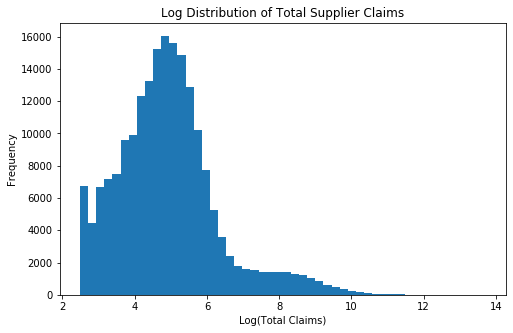

In [44]:
import numpy as np

plt.figure(figsize=(8,5))
plt.hist(np.log1p(df['tot_suplr_clms']), bins=50)
plt.title("Log Distribution of Total Supplier Claims")
plt.xlabel("Log(Total Claims)")
plt.ylabel("Frequency")
plt.show()

**Medicare Payment Distribution**

Explanation:

Total Medicare payments also show a right-skewed distribution similar to claim counts. This confirms that financial exposure is concentrated among a small number of suppliers.

When claim volume and payment volume are both heavily skewed, it indicates:

- Financial risk concentration

- Higher audit priority for top decile suppliers

- Strong justification for anomaly detection methods

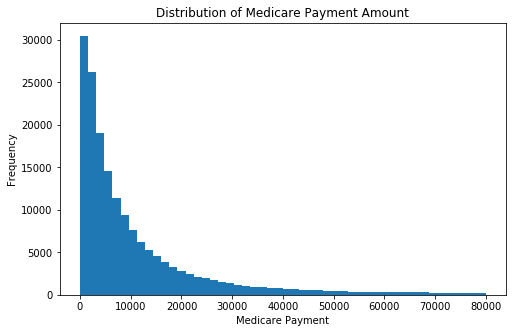

In [45]:
plt.figure(figsize=(8,5))

#Filter to view claim under 80,000
claims = df[df['suplr_mdcr_pymt_amt'] <= 80000]

plt.hist(claims['suplr_mdcr_pymt_amt'], bins=50)
plt.title("Distribution of Medicare Payment Amount")
plt.xlabel("Medicare Payment")
plt.ylabel("Frequency")
plt.show()

**Claims Trend (2021–2023)**

Explanation:

The trend between 2021 and 2023 shows how supplier billing activity changes over time.The trend shows that as the claims increase, the medicare payment amount increase.

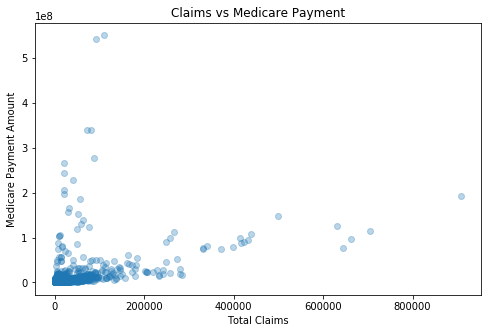

In [46]:
plt.figure(figsize=(8,5))
plt.scatter(df['tot_suplr_clms'], df['suplr_mdcr_pymt_amt'], alpha=0.3)
plt.title("Claims vs Medicare Payment")
plt.xlabel("Total Claims")
plt.ylabel("Medicare Payment Amount")
plt.show()

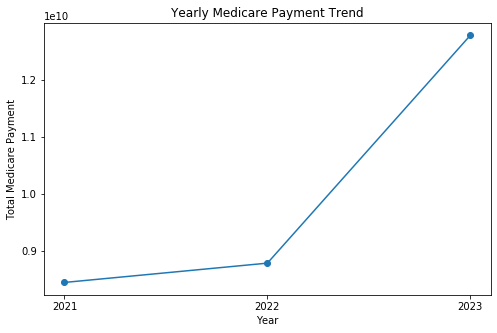

In [47]:
year_payment = df.groupby('year')['suplr_mdcr_pymt_amt'].sum()
plt.figure(figsize=(8,5))
plt.plot(year_payment.index, year_payment.values, marker='o')
plt.title("Yearly Medicare Payment Trend")
plt.xlabel("Year")
plt.ylabel("Total Medicare Payment")
plt.xticks([2021, 2022, 2023])
plt.show()

**Top 10 States by Medicare Payment**

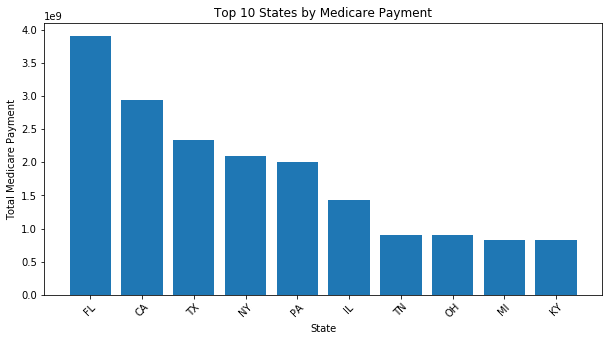

In [48]:
state_payment = df.groupby('suplr_prvdr_state_abrvtn')['suplr_mdcr_pymt_amt'].sum()
top_states = state_payment.sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.bar(top_states.index, top_states.values)
plt.title("Top 10 States by Medicare Payment")
plt.xlabel("State")
plt.ylabel("Total Medicare Payment")
plt.xticks(rotation=45)
plt.show()

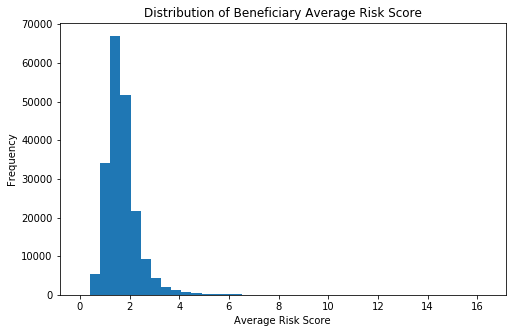

In [49]:
plt.figure(figsize=(8,5))
plt.hist(df['bene_avg_risk_scre'], bins=40)
plt.title("Distribution of Beneficiary Average Risk Score")
plt.xlabel("Average Risk Score")
plt.ylabel("Frequency")
plt.show()

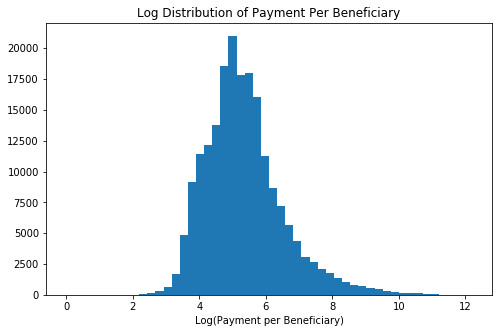

In [50]:
df['payment_per_bene'] = df['suplr_mdcr_pymt_amt'] / df['tot_suplr_benes']
plt.figure(figsize=(8,5))
plt.hist(np.log1p(df['payment_per_bene']), bins=50)
plt.title("Log Distribution of Payment Per Beneficiary")
plt.xlabel("Log(Payment per Beneficiary)")
plt.show()

In [51]:
print("DME Suppression Counts:")
print(df['dme_sprsn_ind'].value_counts())
print("\nPOS Suppression Counts:")
print(df['pos_sprsn_ind'].value_counts())

DME Suppression Counts:
*    10056
#      361
Name: dme_sprsn_ind, dtype: int64

POS Suppression Counts:
#    32811
*     6525
Name: pos_sprsn_ind, dtype: int64


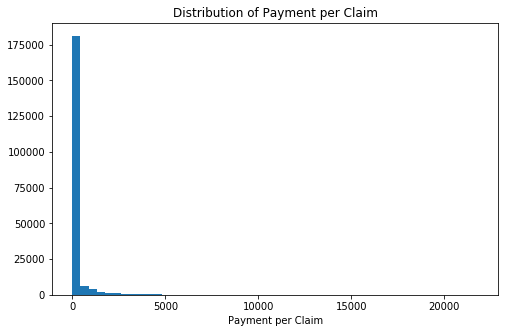

In [52]:
df['payment_per_claim'] = df['suplr_mdcr_pymt_amt'] / df['tot_suplr_clms']

plt.figure(figsize=(8,5))
plt.hist(df['payment_per_claim'].dropna(), bins=50)
plt.title("Distribution of Payment per Claim")
plt.xlabel("Payment per Claim")
plt.show()

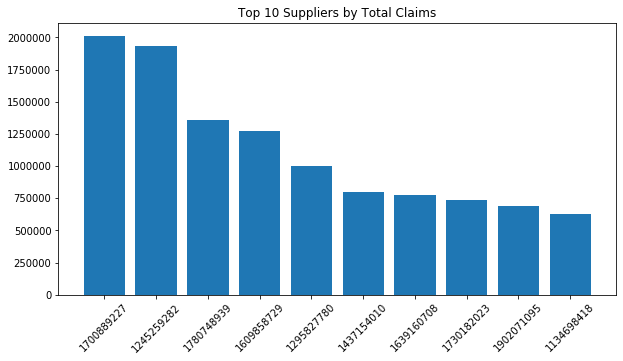

In [53]:
top_suppliers = df.groupby('suplr_npi')['tot_suplr_clms'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_suppliers.index.astype(str), top_suppliers.values)
plt.title("Top 10 Suppliers by Total Claims")
plt.xticks(rotation=45)
plt.show()

In [54]:
print(df[df['suplr_prvdr_last_name_org'] == "united_states_medical_supply_llc"]['suplr_npi'].unique())
print(df[df['suplr_prvdr_last_name_org'] == "north_coast_medical_supply_llc"]['suplr_npi'].unique())
print(df[df['suplr_prvdr_last_name_org'] == "lincare_pharmacy_services_inc"]['suplr_npi'].unique())
print(df[df['suplr_prvdr_last_name_org'] == "rgh_enterprises_llc"]['suplr_npi'].unique())
print(df[df['suplr_prvdr_last_name_org'] == "degc_enterprises_us_inc"]['suplr_npi'].unique())
print(df[df['suplr_prvdr_last_name_org'] == "medstar_surgical_breathing_equipment_inc"]['suplr_npi'].unique())
print(df[df['suplr_prvdr_last_name_org'] == "180_medical_inc"]['suplr_npi'].unique())
print(df[df['suplr_prvdr_last_name_org'] == "ocean_home_health_supply_llc"]['suplr_npi'].unique())
print(df[df['suplr_prvdr_last_name_org'] == "inogen_inc"]['suplr_npi'].unique())
print(df[df['suplr_prvdr_last_name_org'] == "super_care_inc"]['suplr_npi'].unique())

[]
[]
[]
[]
[]
[]
[]
[]
[]
[]


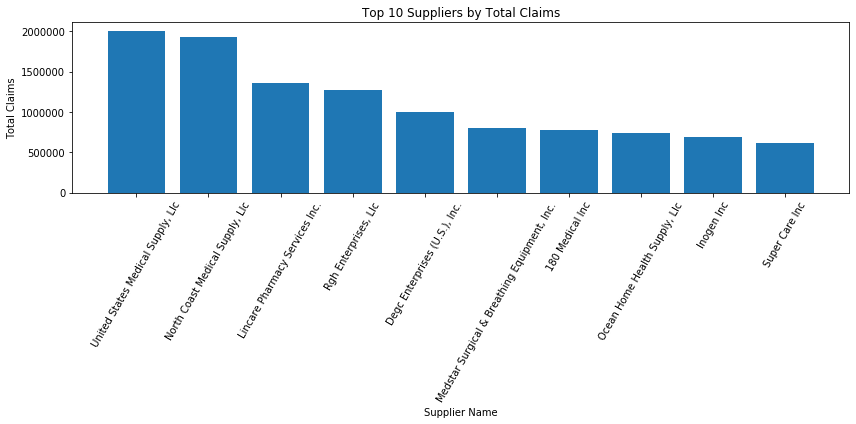

In [55]:
import matplotlib.pyplot as plt

# Group by NPI + Name (keeps suppliers unique)
top_suppliers = (
    df.groupby(['suplr_npi', 'suplr_prvdr_last_name_org'])['tot_suplr_clms']
      .sum()
      .reset_index()
      .sort_values(by='tot_suplr_clms', ascending=False)
      .head(11)
)

plt.figure(figsize=(12,6))

plt.bar(top_suppliers['suplr_prvdr_last_name_org'], 
        top_suppliers['tot_suplr_clms'])

plt.title("Top 10 Suppliers by Total Claims")
plt.xlabel("Supplier Name")
plt.ylabel("Total Claims")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()